# Weekend 1 — Explore MovieLens

**Goal:** understand the data well enough to build the model next weekend.
Not to build the model. Resist the urge.

By the end you should be able to answer, from memory:

1. How sparse is the ratings matrix, and why does that force sparse storage?
2. What does the rating distribution look like, and why does that matter for
   centering?
3. How many movies can I actually map to a TMDB id?
4. Why is "average rating" a broken way to rank movies?

Run `python download_data.py` first if you haven't.

---
## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAW = Path("../data/raw/ml-latest-small")

ratings = pd.read_csv(RAW / "ratings.csv")
movies = pd.read_csv(RAW / "movies.csv")
links = pd.read_csv(RAW / "links.csv")

print("ratings", ratings.shape)
print("movies ", movies.shape)
print("links  ", links.shape)
ratings.head()

ratings (100836, 4)
movies  (9742, 3)
links   (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


`ratings.csv` is the entire model input: one row per (user, movie, rating).
`movies.csv` and `links.csv` are metadata — titles for display, and the
bridge to TMDB ids.

## 1. How big is the problem?

In [2]:
n_users = ratings.userId.nunique()
n_rated_movies = ratings.movieId.nunique()
n_catalog = movies.movieId.nunique()

print(f"users in ratings      : {n_users:,}")
print(f"movies WITH ratings   : {n_rated_movies:,}")
print(f"movies in catalog     : {n_catalog:,}")
print(f"movies with NO ratings: {n_catalog - n_rated_movies:,}  <-- invisible to CF")

cells = n_users * n_rated_movies
density = len(ratings) / cells
print(f"\nmatrix                : {n_users:,} x {n_rated_movies:,} = {cells:,} cells")
print(f"actual ratings        : {len(ratings):,}")
print(f"density               : {density:.2%}  (sparsity {1 - density:.2%})")

users in ratings      : 610
movies WITH ratings   : 9,724
movies in catalog     : 9,742
movies with NO ratings: 18  <-- invisible to CF

matrix                : 610 x 9,724 = 5,931,640 cells
actual ratings        : 100,836
density               : 1.70%  (sparsity 98.30%)


**Notice:** ~98% of the matrix is empty. Two consequences that shape everything:

- Storing it densely wastes almost all of the memory (quantified below).
- Those movies with zero ratings **cannot be recommended by collaborative
  filtering at all**. That is the item cold-start problem, and it is a real
  limitation of the model you're about to build — not a bug to fix. Be ready
  to say so in an interview.

In [3]:
from scipy.sparse import csr_matrix

user_codes = ratings.userId.astype("category").cat.codes
movie_codes = ratings.movieId.astype("category").cat.codes

R = csr_matrix(
    (ratings.rating.astype("float32"), (user_codes, movie_codes)),
    shape=(n_users, n_rated_movies),
)

dense_mb = cells * 4 / 1e6  # float32
sparse_mb = (R.data.nbytes + R.indices.nbytes + R.indptr.nbytes) / 1e6

print(f"R = {R.shape}, stored values: {R.nnz:,}")
print(f"dense  float32 : {dense_mb:8.1f} MB")
print(f"sparse CSR     : {sparse_mb:8.1f} MB   ({dense_mb / sparse_mb:.0f}x smaller)")

R = (610, 9724), stored values: 100,836
dense  float32 :     23.7 MB
sparse CSR     :      0.8 MB   (29x smaller)


That ratio is the entire argument for `scipy.sparse`. At this size dense would
still *fit* — but the same calculation on the full 25M-rating dataset gives
tens of GB, so learn the sparse habit now.

**Worth understanding:** CSR stores three arrays — `data` (the values),
`indices` (which column each value is in), and `indptr` (where each row
starts). Print `R.indptr[:5]` and `R.indices[:10]` and convince yourself how
row 0 is reconstructed.

## 2. What do the ratings look like?

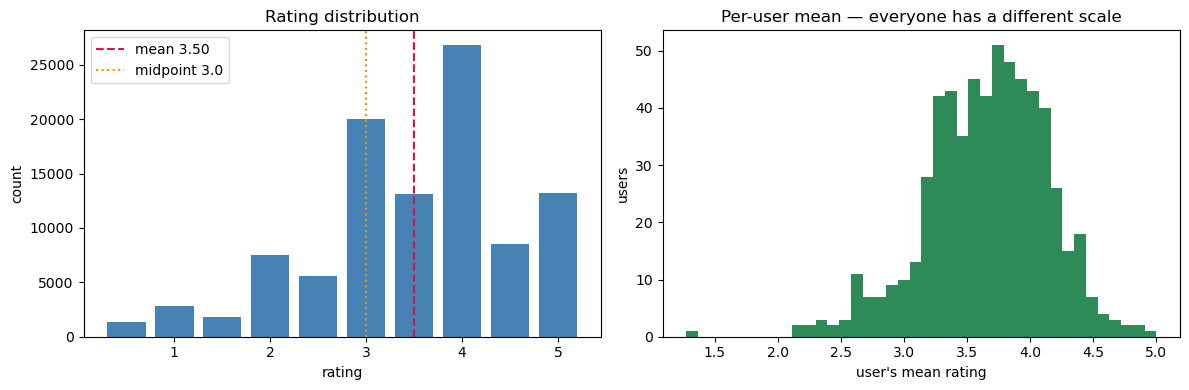

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

counts = ratings.rating.value_counts().sort_index()
ax[0].bar(counts.index, counts.values, width=0.4, color="steelblue")
ax[0].axvline(ratings.rating.mean(), color="crimson", ls="--",
              label=f"mean {ratings.rating.mean():.2f}")
ax[0].axvline(3.0, color="darkorange", ls=":", label="midpoint 3.0")
ax[0].set(xlabel="rating", ylabel="count", title="Rating distribution")
ax[0].legend()

user_means = ratings.groupby("userId").rating.mean()
ax[1].hist(user_means, bins=40, color="seagreen")
ax[1].set(xlabel="user's mean rating", ylabel="users",
          title="Per-user mean — everyone has a different scale")

plt.tight_layout()
plt.show()

print(ratings.rating.describe())

**Notice three things:**

1. Ratings run 0.5–5.0 in half-steps, and the distribution is **skewed high** —
   the mean is ~3.5, not 3.0. People rate things they chose to watch.
2. Whole stars are far more common than half stars. Users round.
3. The per-user means spread widely. One user's 3★ is another's 5★.

This is *why the model must center ratings* before computing similarity. If you
feed in raw 1–5 values, every term in the similarity sum is positive, so a 1★
rating still nudges the model *toward* similar movies. Subtracting a midpoint
(or better, each user's own mean) is what makes a dislike push away.

Try it yourself — this is the single most important cell in the notebook:

In [5]:
raw = ratings.rating
centered_mid = ratings.rating - 3.0
centered_user = ratings.rating - ratings.groupby("userId").rating.transform("mean")

for name, s in [("raw", raw), ("minus 3.0", centered_mid), ("minus user mean", centered_user)]:
    print(f"{name:<16} mean={s.mean():+.3f}  min={s.min():+.2f}  max={s.max():+.2f}  "
          f"pct negative={100 * (s < 0).mean():.1f}%")

raw              mean=+3.502  min=+0.50  max=+5.00  pct negative=0.0%
minus 3.0        mean=+0.502  min=-2.50  max=+2.00  pct negative=18.9%
minus user mean  mean=+0.000  min=-4.02  max=+2.78  pct negative=45.7%


With raw ratings, **0% of signal is negative**. After centering on the user's
own mean, roughly half is. That's the difference between a model that
understands dislike and one that doesn't.

## 3. The long tail

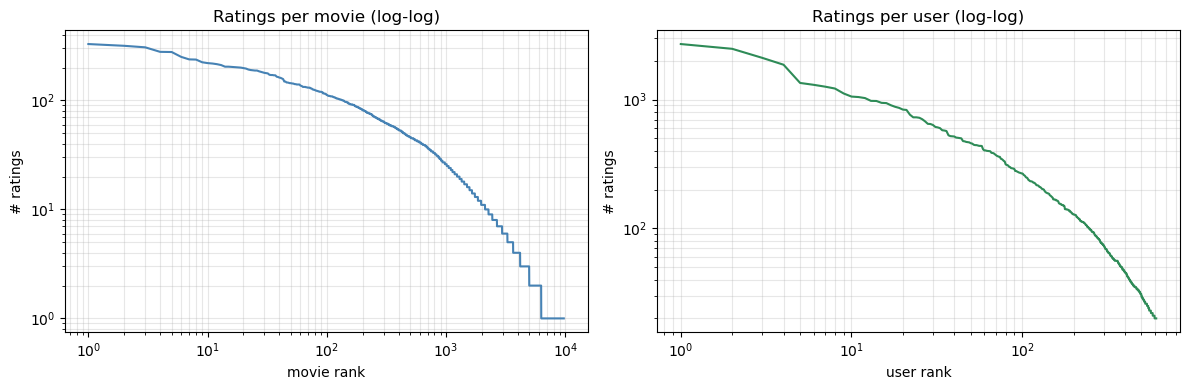

ratings per movie: {'mean': 10.369806663924312, '50%': 3.0, 'max': 329.0}
ratings per user : {'mean': 165.30491803278687, '50%': 70.5, 'max': 2698.0}

movies with 1 rating   : 3,446 (35% of rated movies)
movies with < 5 ratings: 6,074 (62%)

top 10% of movies hold : 60% of all ratings


In [6]:
per_movie = ratings.groupby("movieId").size().sort_values(ascending=False)
per_user = ratings.groupby("userId").size().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].loglog(range(1, len(per_movie) + 1), per_movie.values, color="steelblue")
ax[0].set(xlabel="movie rank", ylabel="# ratings", title="Ratings per movie (log-log)")
ax[0].grid(alpha=0.3, which="both")

ax[1].loglog(range(1, len(per_user) + 1), per_user.values, color="seagreen")
ax[1].set(xlabel="user rank", ylabel="# ratings", title="Ratings per user (log-log)")
ax[1].grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

print("ratings per movie:", per_movie.describe()[["mean", "50%", "max"]].to_dict())
print("ratings per user :", per_user.describe()[["mean", "50%", "max"]].to_dict())
print(f"\nmovies with 1 rating   : {(per_movie == 1).sum():,} "
      f"({(per_movie == 1).mean():.0%} of rated movies)")
print(f"movies with < 5 ratings: {(per_movie < 5).sum():,} "
      f"({(per_movie < 5).mean():.0%})")
print(f"\ntop 10% of movies hold : {per_movie.head(len(per_movie) // 10).sum() / len(ratings):.0%} "
      f"of all ratings")

A near-straight line on a log-log plot means a power law: a few movies have
thousands of ratings, most have a handful.

**This is why shrinkage matters.** Two obscure movies rated by the same 2 users
get a cosine similarity of 1.0 — perfect twins, on evidence of two people.
Next weekend you'll multiply each similarity by `n_co / (n_co + λ)` to pull
low-evidence pairs toward zero. This plot is the reason.

## 4. Why "average rating" is a broken ranking

In [7]:
stats = (
    ratings.groupby("movieId")
    .rating.agg(n="size", mean="mean")
    .merge(movies.set_index("movieId")[["title"]], left_index=True, right_index=True)
)

print("=== TOP 10 BY RAW MEAN RATING ===")
print(stats.sort_values("mean", ascending=False).head(10).to_string())

print("\n=== TOP 10 BY NUMBER OF RATINGS ===")
print(stats.sort_values("n", ascending=False).head(10)[["n", "mean", "title"]].to_string())

=== TOP 10 BY RAW MEAN RATING ===
         n  mean                                      title
movieId                                                    
88448    1   5.0      Paper Birds (Pájaros de papel) (2010)
100556   1   5.0                 Act of Killing, The (2012)
143031   1   5.0                            Jump In! (2007)
143511   1   5.0                               Human (2015)
143559   1   5.0                        L.A. Slasher (2015)
6201     1   5.0                           Lady Jane (1986)
102217   1   5.0             Bill Hicks: Revelations (1993)
102084   1   5.0               Justice League: Doom (2012) 
6192     1   5.0  Open Hearts (Elsker dig for evigt) (2002)
145994   1   5.0                     Formula of Love (1984)

=== TOP 10 BY NUMBER OF RATINGS ===
           n      mean                                      title
movieId                                                          
356      329  4.164134                        Forrest Gump (1994)
318      31

The first list is garbage: films with a single 5.0 rating. The second is
recognizable.

This is exactly the trap your **popularity baseline** must avoid next weekend.
Rank by rating *count*, or by a shrunk mean:

$$\text{score} = \frac{n \cdot \bar{r} + m \cdot \bar{r}_{\text{global}}}{n + m}$$

which pulls low-count movies toward the global average.

In [8]:
GLOBAL_MEAN = ratings.rating.mean()
M = 20  # shrinkage strength: "pretend every movie has 20 prior ratings"

stats["shrunk"] = (stats.n * stats["mean"] + M * GLOBAL_MEAN) / (stats.n + M)

print("=== TOP 10 BY SHRUNK MEAN (the honest baseline) ===")
print(stats.sort_values("shrunk", ascending=False).head(10).to_string())

=== TOP 10 BY SHRUNK MEAN (the honest baseline) ===
           n      mean                                                  title    shrunk
movieId                                                                                
318      317  4.429022                       Shawshank Redemption, The (1994)  4.373980
858      192  4.289062                                  Godfather, The (1972)  4.214770
2959     218  4.272936                                      Fight Club (1999)  4.208114
260      251  4.231076              Star Wars: Episode IV - A New Hope (1977)  4.177237
50       204  4.237745                             Usual Suspects, The (1995)  4.172014
527      220  4.225000                                Schindler's List (1993)  4.164713
1221     129  4.259690                         Godfather: Part II, The (1974)  4.157927
296      307  4.197068                                    Pulp Fiction (1994)  4.154529
1196     211  4.215640  Star Wars: Episode V - The Empire Strikes Ba

Now the list looks like a list of good films. **Make your popularity baseline
this, not the raw mean** — a baseline you've deliberately weakened proves
nothing when your model beats it.

## 5. TMDB id coverage

The API will speak TMDB ids, so every movie you serve needs one. Check now,
not at request time.

In [9]:
missing = links.tmdbId.isna().sum()
print(f"catalog movies     : {len(links):,}")
print(f"missing tmdbId     : {missing}  ({missing / len(links):.2%})")
print(f"duplicate tmdbIds  : {links.tmdbId.dropna().duplicated().sum()}")

rated_ids = set(ratings.movieId.unique())
usable = links[links.tmdbId.notna() & links.movieId.isin(rated_ids)]
print(f"\nSERVEABLE (has tmdbId AND >=1 rating): {len(usable):,}")
print("^ this is the real catalog size. Write it in your README.")

links[links.tmdbId.isna()].merge(movies, on="movieId")[["movieId", "title"]]

catalog movies     : 9,742
missing tmdbId     : 8  (0.08%)
duplicate tmdbIds  : 1

SERVEABLE (has tmdbId AND >=1 rating): 9,716
^ this is the real catalog size. Write it in your README.


,movieId,title
0,791,"Last Klezmer: Leopold Kozlowski, His Life and ..."
1,1107,Loser (1991)
2,2851,Saturn 3 (1980)
3,4051,Horrors of Spider Island (Ein Toter Hing im Ne...
4,26587,"Decalogue, The (Dekalog) (1989)"
5,32600,Eros (2004)
6,40697,Babylon 5
7,79299,"No. 1 Ladies' Detective Agency, The (2008)"


**Notice** the duplicate-tmdbId count. Two MovieLens rows can point at the same
TMDB film, so `tmdb_id -> movieId` is not a clean one-to-one map. Decide the
tie-break rule now (keep the one with more ratings) rather than discovering it
as a duplicate row in your API response.

## 6. Genres

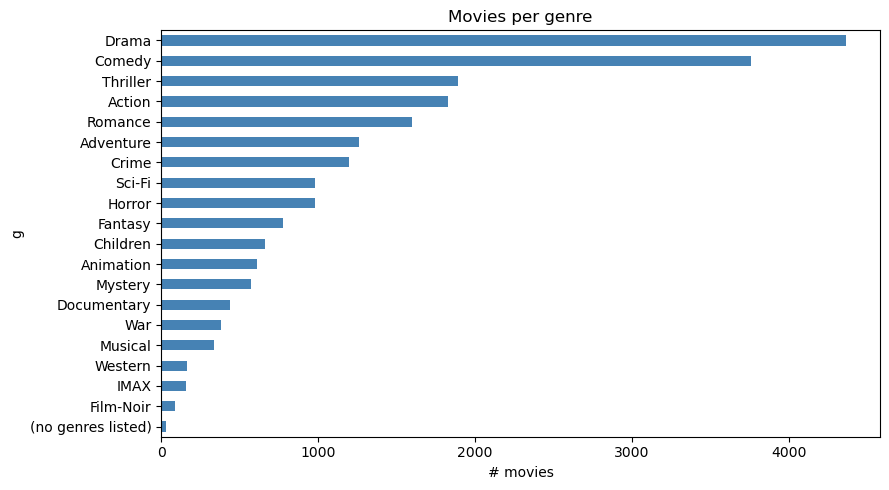

g
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34

movies per genre label: mean 2.27


In [10]:
exploded = movies.assign(g=movies.genres.str.split("|")).explode("g")
genre_counts = exploded.g.value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
genre_counts.iloc[::-1].plot.barh(ax=ax, color="steelblue")
ax.set(xlabel="# movies", title="Movies per genre")
plt.tight_layout()
plt.show()

print(genre_counts.to_string())
print(f"\nmovies per genre label: mean {exploded.groupby('movieId').size().mean():.2f}")

Genres are pipe-separated and multi-label, with a literal
`(no genres listed)` value to handle. You need these for the filters in
weekend 5, and as a sanity check in weekend 2: the neighbors of *Toy Story*
should be mostly Animation/Children.

## 7. Timestamps — can I do a chronological split?

Weekend 3 needs to hold out each user's **last** rating by time. Verify that's
actually possible.

date range: 1996-03-29 -> 2018-09-24

users rating everything within 1 day: 362 of 610 (59%)
median active span: 0 days


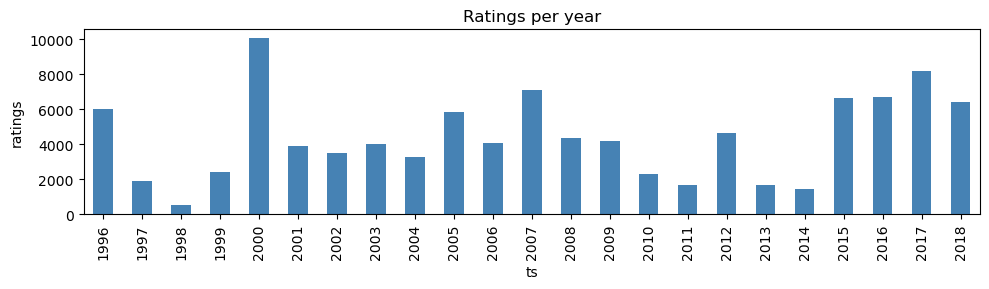

In [11]:
ratings["ts"] = pd.to_datetime(ratings.timestamp, unit="s")
print(f"date range: {ratings.ts.min().date()} -> {ratings.ts.max().date()}")

span = ratings.groupby("userId").ts.agg(["min", "max", "count"])
span["days"] = (span["max"] - span["min"]).dt.days

print(f"\nusers rating everything within 1 day: {(span.days == 0).sum()} "
      f"of {len(span)} ({(span.days == 0).mean():.0%})")
print(f"median active span: {span.days.median():.0f} days")

per_year = ratings.ts.dt.year.value_counts().sort_index()
per_year.plot.bar(figsize=(10, 3), title="Ratings per year", ylabel="ratings",
                  color="steelblue")
plt.tight_layout()
plt.show()

**Notice:** many users rated everything in a single session. For those, "last
rating by timestamp" is close to arbitrary — the ordering within a session
carries little signal.

That's a genuine weakness of leave-one-out on this dataset, and worth saying
out loud rather than hiding. Do it anyway: a chronological split cannot leak
the future, and a random split can. **An honest weak split beats a dishonest
strong one.**

## 8. Findings

Fill these in from your own output, then move to weekend 2.

In [12]:
print(f"""
WEEKEND 1 FINDINGS
------------------
users                    {n_users:,}
movies with ratings      {n_rated_movies:,}
serveable catalog        {len(usable):,}   (has tmdbId and >=1 rating)
ratings                  {len(ratings):,}
density                  {density:.2%}
global mean rating       {GLOBAL_MEAN:.3f}
movies with <5 ratings   {(per_movie < 5).mean():.0%}
date range               {ratings.ts.min().date()} -> {ratings.ts.max().date()}

CARRY INTO WEEKEND 2
--------------------
1. Build R as sparse CSR       ({dense_mb / sparse_mb:.0f}x smaller than dense here,
                                and the gap grows with dataset size)
2. Center before similarity    (raw ratings are 0% negative -> cannot model dislike)
3. Shrink by co-rating count   ({(per_movie < 5).mean():.0%} of movies have <5 ratings)
4. Baseline = shrunk mean      (raw mean returns films with one 5.0 vote)
5. Keep top-50 neighbours      (don't materialise the full {n_rated_movies:,}^2 matrix)
6. Tie-break duplicate tmdbIds (prefer the movieId with more ratings)

DO NOT build the model in this notebook. Weekend 2 is train.py.
""")


WEEKEND 1 FINDINGS
------------------
users                    610
movies with ratings      9,724
serveable catalog        9,716   (has tmdbId and >=1 rating)
ratings                  100,836
density                  1.70%
global mean rating       3.502
movies with <5 ratings   62%
date range               1996-03-29 -> 2018-09-24

CARRY INTO WEEKEND 2
--------------------
1. Build R as sparse CSR       (29x smaller than dense here,
                                and the gap grows with dataset size)
2. Center before similarity    (raw ratings are 0% negative -> cannot model dislike)
3. Shrink by co-rating count   (62% of movies have <5 ratings)
4. Baseline = shrunk mean      (raw mean returns films with one 5.0 vote)
5. Keep top-50 neighbours      (don't materialise the full 9,724^2 matrix)
6. Tie-break duplicate tmdbIds (prefer the movieId with more ratings)

DO NOT build the model in this notebook. Weekend 2 is train.py.

